In [6]:
!pip install xgboost lightgbm imbalanced-learn shap -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
X = df.drop(columns=['F3924'])
y = df['F3924']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

key_features = ['F115','F321','F527','F531','F670','F1692',
                'F2082','F2122','F2582','F2678','F2737','F2956',
                'F3043','F3836','F3887','F3889','F3891','F3894']
X = X[key_features]

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nMules caught : {cm[1][1]} / {y_test.sum()}")
print(f"Mules missed : {cm[1][0]}")
print(f"False alarms : {cm[0][1]}")

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_new = (y_prob > threshold).astype(int)
    cm2 = confusion_matrix(y_test, y_new)
    print(f"  {threshold} → Caught: {cm2[1][1]}/{y_test.sum()} | "
          f"Recall: {recall_score(y_test, y_new)*100:.0f}% | "
          f"False alarms: {cm2[0][1]}")

Saving DataSet.csv to DataSet (2).csv
AUC-ROC   : 0.939
Recall    : 56.2%
Precision : 8.2%
F1 Score  : 0.143

Mules caught : 9 / 16
Mules missed : 7
False alarms : 101

Threshold Tuning:
  0.5 → Caught: 9/16 | Recall: 56% | False alarms: 101
  0.4 → Caught: 11/16 | Recall: 69% | False alarms: 151
  0.3 → Caught: 13/16 | Recall: 81% | False alarms: 219
  0.2 → Caught: 16/16 | Recall: 100% | False alarms: 306
  0.1 → Caught: 16/16 | Recall: 100% | False alarms: 483


In [ ]:
y_pred_final = (y_prob > 0.2).astype(int)

In [ ]:
y_pred_final = (y_prob > 0.3).astype(int)

Saving DataSet.csv to DataSet (1).csv
AUC-ROC   : 0.939
Recall    : 56.2%
Precision : 8.2%
F1 Score  : 0.143

Mules caught : 9 / 16
Mules missed : 7
False alarms : 101

Threshold Tuning:
  0.5 → Caught: 9/16 | Recall: 56% | False alarms: 101
  0.4 → Caught: 11/16 | Recall: 69% | False alarms: 151
  0.3 → Caught: 13/16 | Recall: 81% | False alarms: 219
  0.2 → Caught: 16/16 | Recall: 100% | False alarms: 306
  0.1 → Caught: 16/16 | Recall: 100% | False alarms: 483

Final Model (threshold 0.3):
Mules caught : 13 / 16
False alarms : 219
Recall       : 81.2%

5-Fold Cross Validation:
  Fold 1: AUC = 0.800
  Fold 2: AUC = 0.809
  Fold 3: AUC = 0.797
  Fold 4: AUC = 0.878
  Fold 5: AUC = 0.803
  Average AUC: 0.817


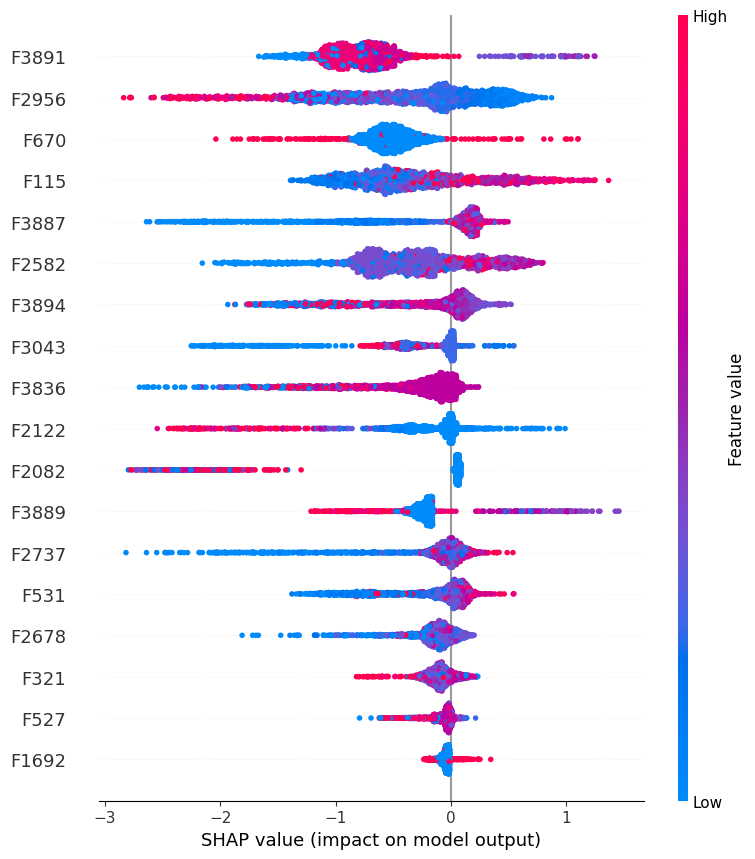

SHAP plot saved!


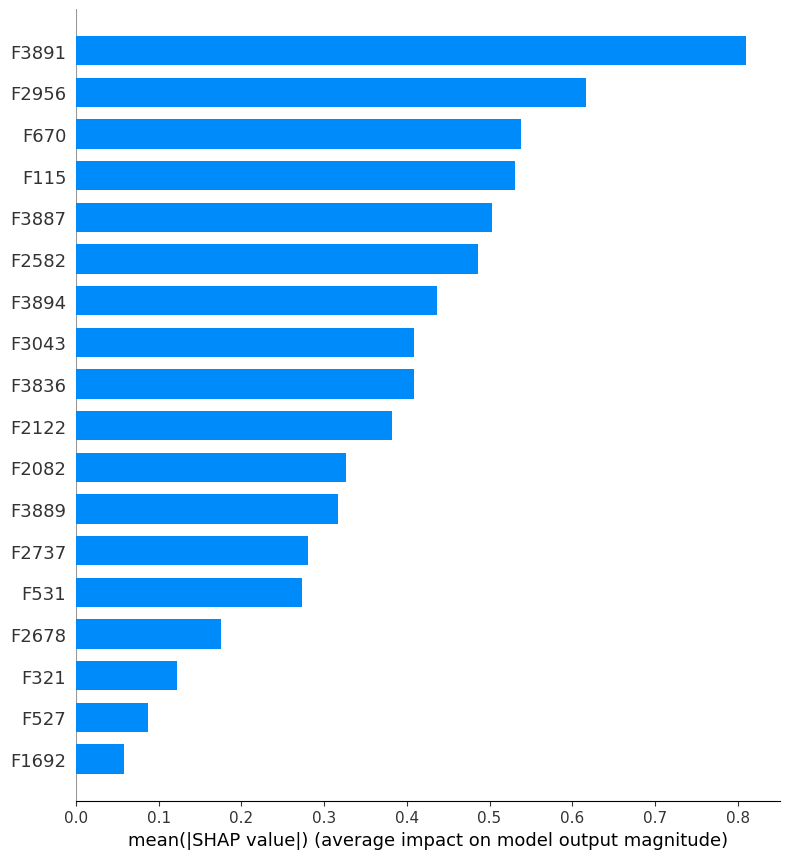

SHAP bar chart saved!


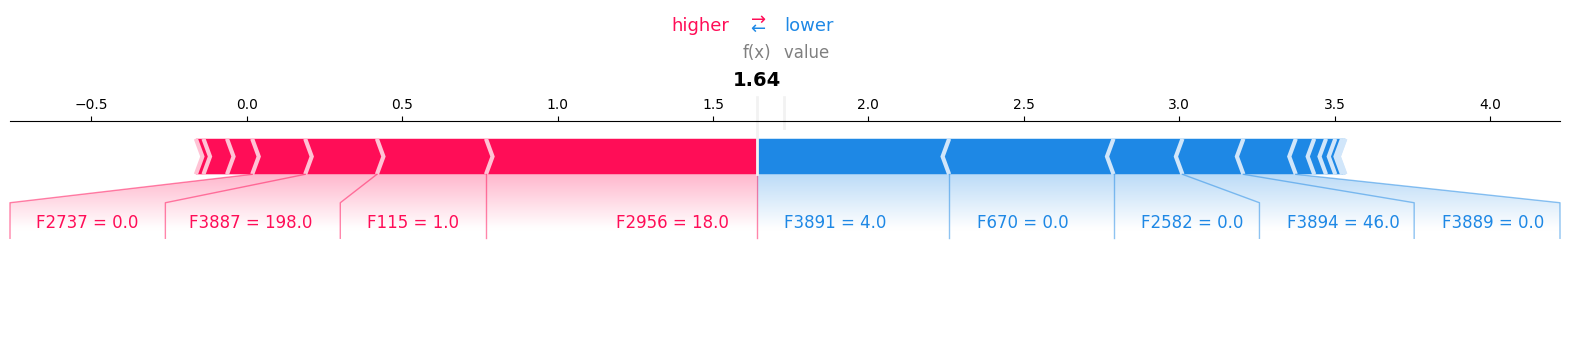

SHAP force plot saved!


In [ ]:
!pip install xgboost lightgbm imbalanced-learn shap -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
X = df.drop(columns=['F3924'])
y = df['F3924']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

key_features = ['F115','F321','F527','F531','F670','F1692',
                'F2082','F2122','F2582','F2678','F2737','F2956',
                'F3043','F3836','F3887','F3889','F3891','F3894']
X = X[key_features]

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
cm = confusion_matrix(y_test, y_pred)
print(f"\nMules caught : {cm[1][1]} / {y_test.sum()}")
print(f"Mules missed : {cm[1][0]}")
print(f"False alarms : {cm[0][1]}")

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_new = (y_prob > threshold).astype(int)
    cm2 = confusion_matrix(y_test, y_new)
    print(f"  {threshold} → Caught: {cm2[1][1]}/{y_test.sum()} | "
          f"Recall: {recall_score(y_test, y_new)*100:.0f}% | "
          f"False alarms: {cm2[0][1]}")

y_pred_final = (y_prob > 0.3).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\nFinal Model (threshold 0.3):")
print(f"Mules caught : {cm_final[1][1]} / {y_test.sum()}")
print(f"False alarms : {cm_final[0][1]}")
print(f"Recall       : {recall_score(y_test, y_pred_final)*100:.1f}%")

print("\n5-Fold Cross Validation:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_imp, y)):
    X_tr, X_te = X_imp[tr_idx], X_imp[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    sm2 = SMOTE(random_state=42, k_neighbors=5)
    X_tr_b, y_tr_b = sm2.fit_resample(X_tr, y_tr)
    m = xgb.XGBClassifier(n_estimators=100, max_depth=4,
                           learning_rate=0.1, verbosity=0,
                           eval_metric='logloss')
    m.fit(X_tr_b, y_tr_b)
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    auc_scores.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.3f}")
print(f"  Average AUC: {np.mean(auc_scores):.3f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar chart saved!")

mule_indices = np.where(y_test == 1)[0]
if len(mule_indices) > 0:
    shap.force_plot(
        explainer.expected_value,
        shap_values[mule_indices[0]],
        X_test[mule_indices[0]],
        feature_names=key_features,
        matplotlib=True,
        show=False
    )
    plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP force plot saved!")

Saving DataSet.csv to DataSet (1).csv
AUC-ROC   : 0.939
Recall    : 56.2%
Precision : 8.2%
F1 Score  : 0.143

Mules caught : 9 / 16
Mules missed : 7
False alarms : 101

Threshold Tuning:
  0.5 → Caught: 9/16 | Recall: 56% | False alarms: 101
  0.4 → Caught: 11/16 | Recall: 69% | False alarms: 151
  0.3 → Caught: 13/16 | Recall: 81% | False alarms: 219
  0.2 → Caught: 16/16 | Recall: 100% | False alarms: 306
  0.1 → Caught: 16/16 | Recall: 100% | False alarms: 483

Final Model (threshold 0.3):
Mules caught : 13 / 16
False alarms : 219
Recall       : 81.2%

5-Fold Cross Validation:
  Fold 1: AUC = 0.800
  Fold 2: AUC = 0.809
  Fold 3: AUC = 0.797
  Fold 4: AUC = 0.878
  Fold 5: AUC = 0.803
  Average AUC: 0.817


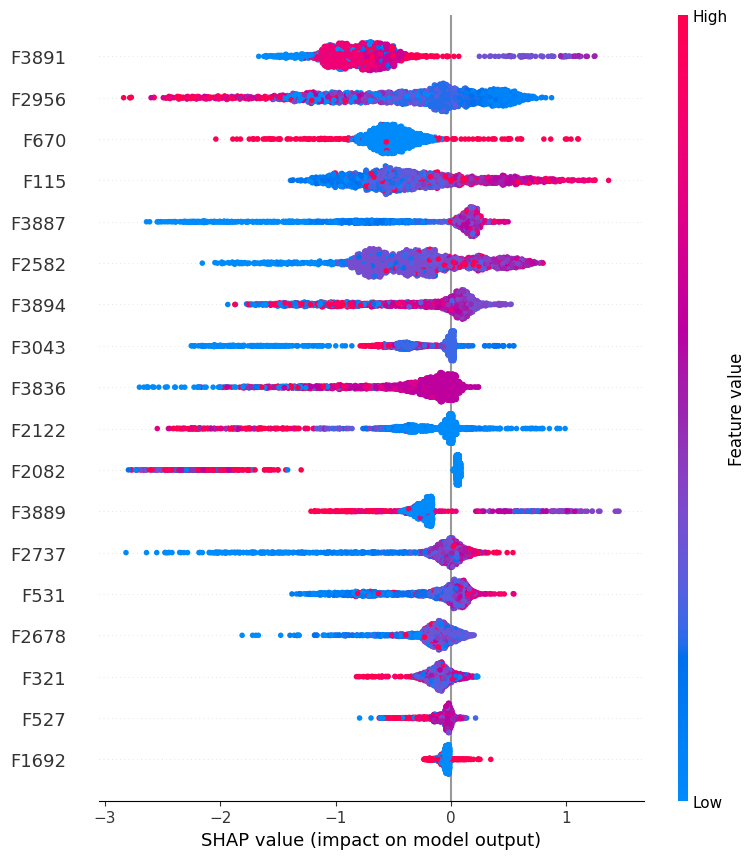

SHAP summary saved!


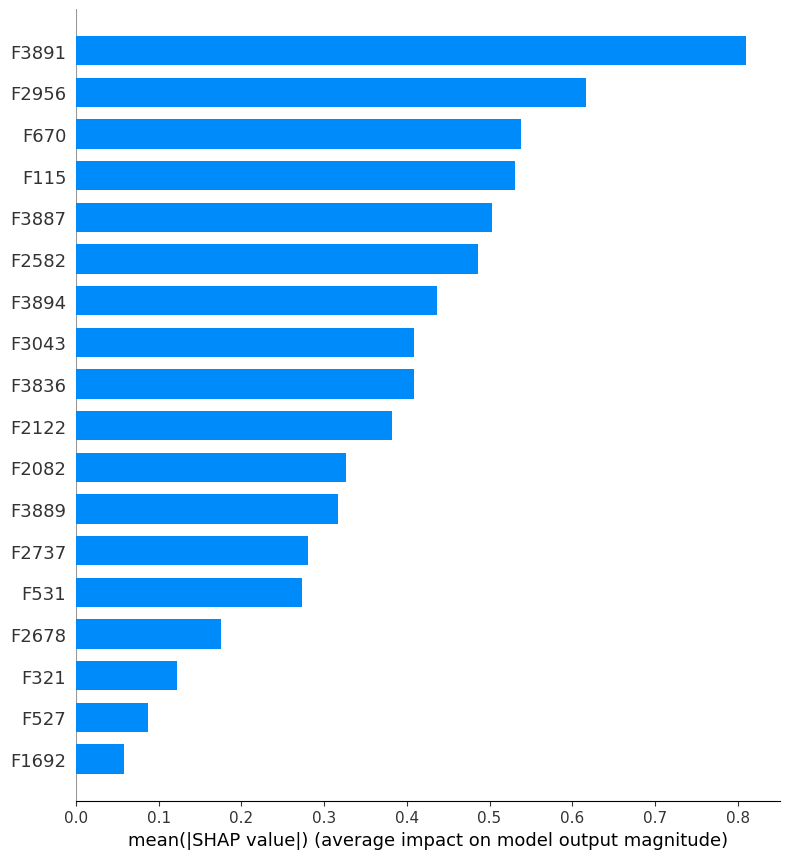

SHAP bar saved!


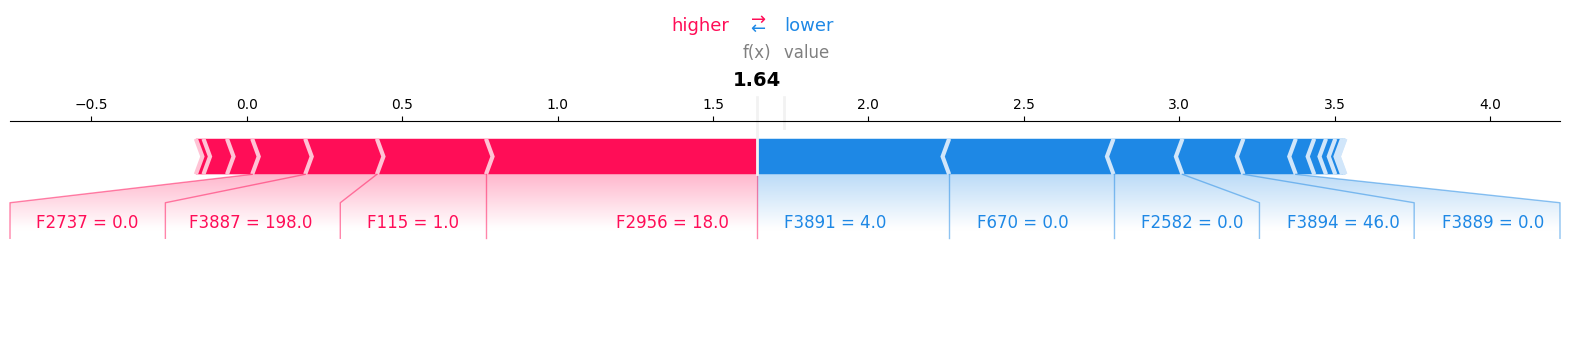

SHAP force plot saved!


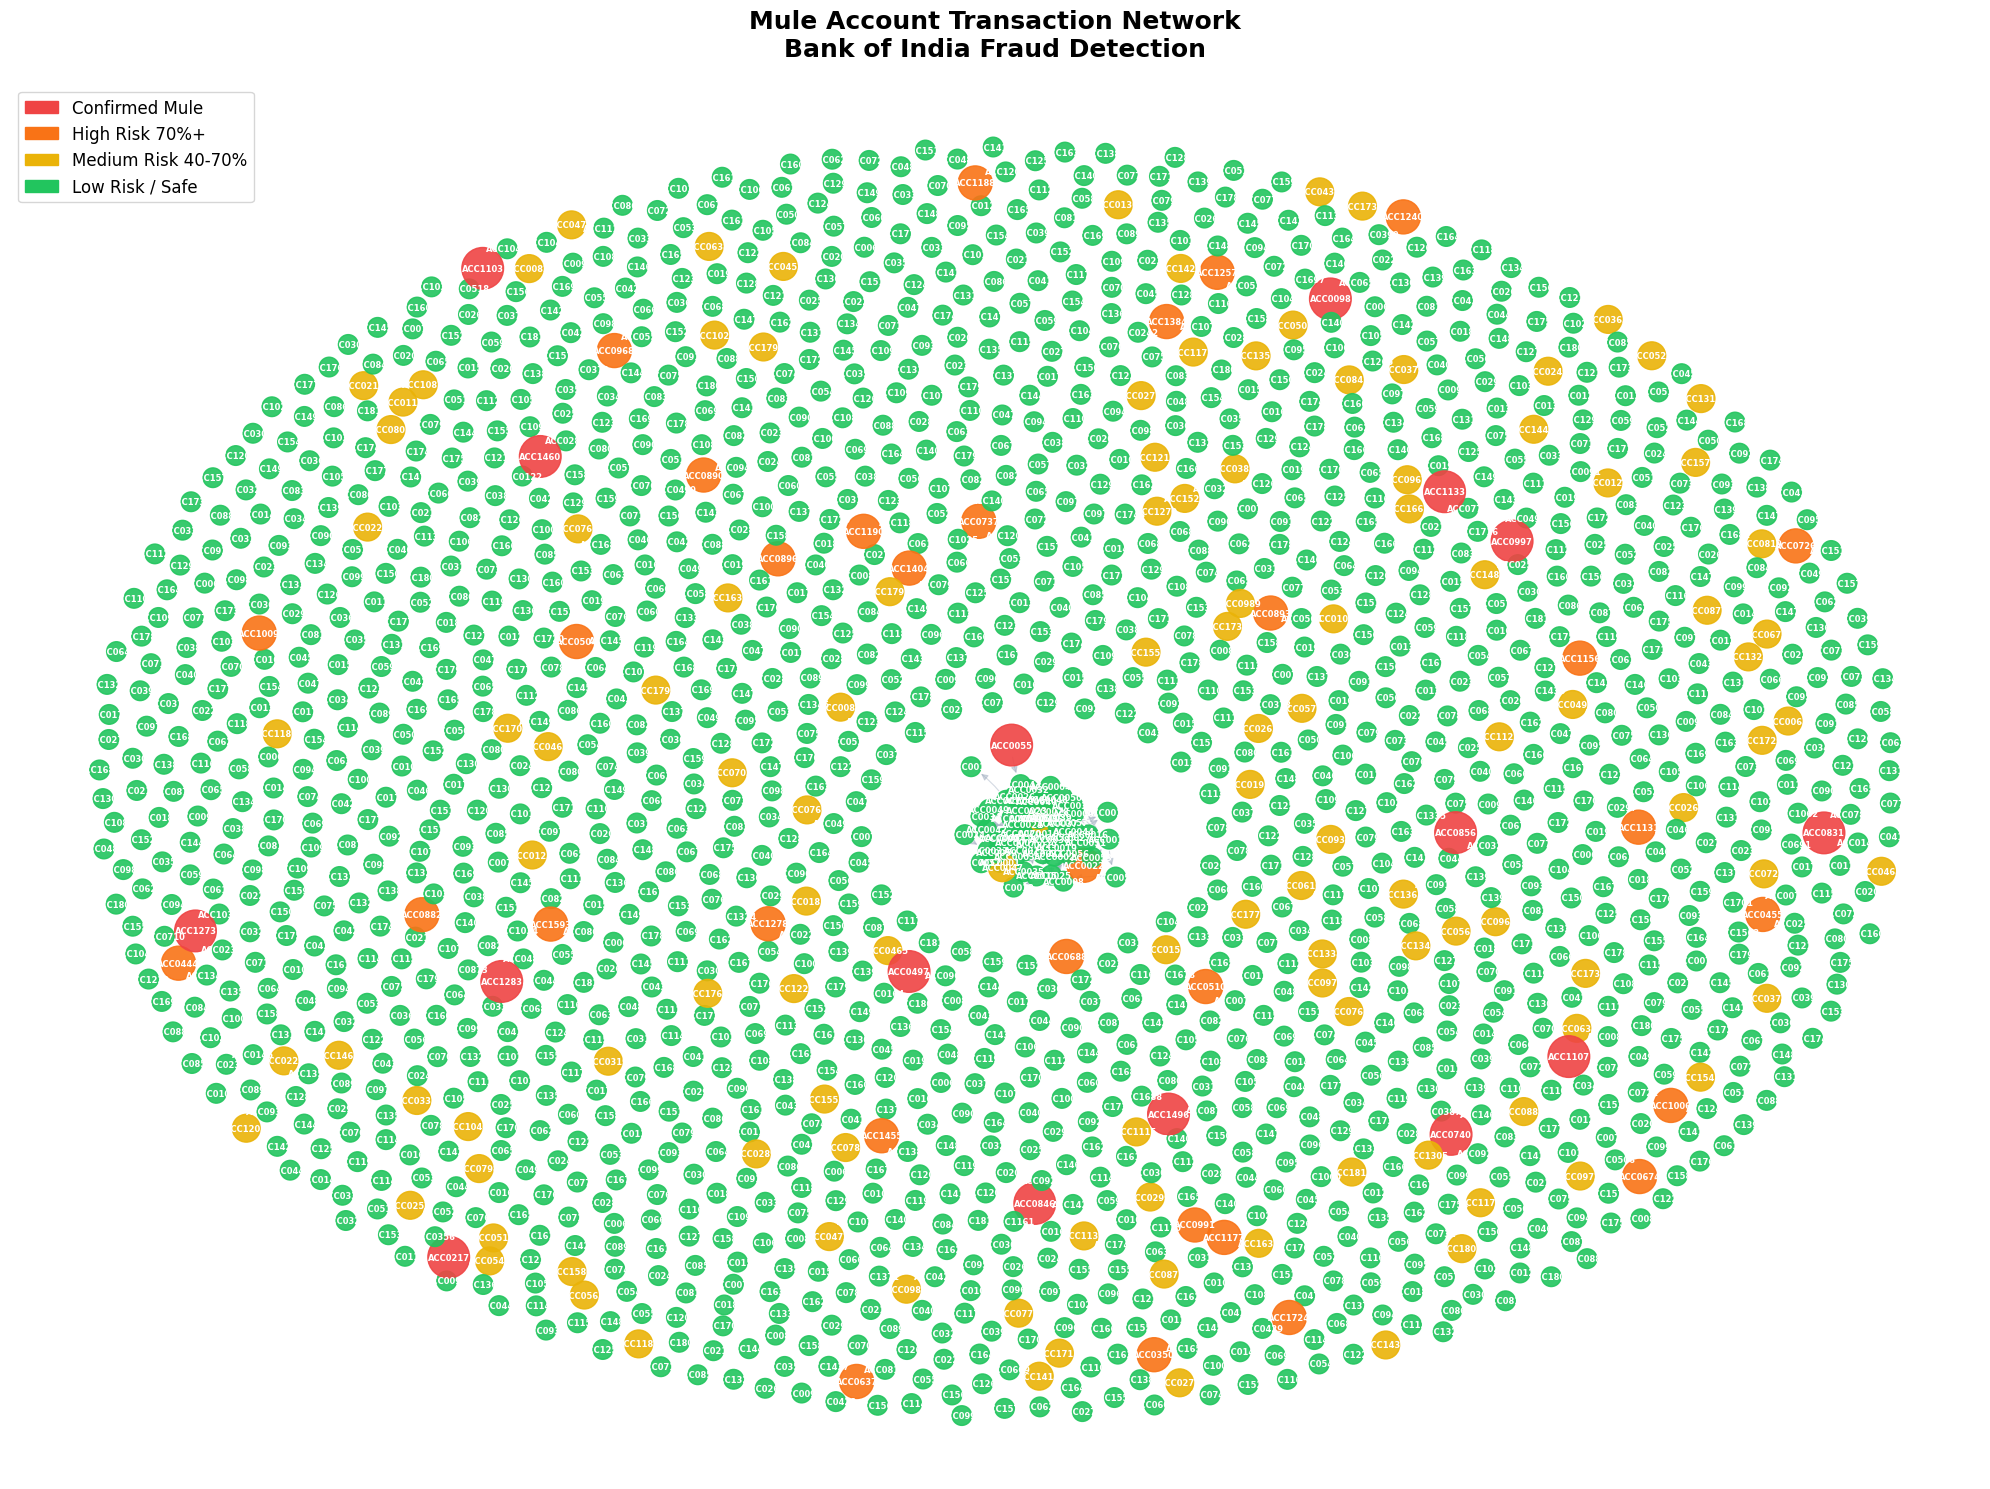

Network graph saved!
Interactive network saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


In [5]:
!pip install xgboost lightgbm imbalanced-learn shap networkx pyvis -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyvis.network import Network
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
X = df.drop(columns=['F3924'])
y = df['F3924']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

key_features = ['F115','F321','F527','F531','F670','F1692',
                'F2082','F2122','F2582','F2678','F2737','F2956',
                'F3043','F3836','F3887','F3889','F3891','F3894']
X = X[key_features]

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4,
    learning_rate=0.1, scale_pos_weight=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0)*100:.1f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
cm = confusion_matrix(y_test, y_pred)
print(f"\nMules caught : {cm[1][1]} / {y_test.sum()}")
print(f"Mules missed : {cm[1][0]}")
print(f"False alarms : {cm[0][1]}")

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_new = (y_prob > threshold).astype(int)
    cm2 = confusion_matrix(y_test, y_new)
    print(f"  {threshold} → Caught: {cm2[1][1]}/{y_test.sum()} | "
          f"Recall: {recall_score(y_test, y_new)*100:.0f}% | "
          f"False alarms: {cm2[0][1]}")

y_pred_final = (y_prob > 0.3).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\nFinal Model (threshold 0.3):")
print(f"Mules caught : {cm_final[1][1]} / {y_test.sum()}")
print(f"False alarms : {cm_final[0][1]}")
print(f"Recall       : {recall_score(y_test, y_pred_final)*100:.1f}%")

print("\n5-Fold Cross Validation:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_imp, y)):
    X_tr, X_te = X_imp[tr_idx], X_imp[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    sm2 = SMOTE(random_state=42, k_neighbors=5)
    X_tr_b, y_tr_b = sm2.fit_resample(X_tr, y_tr)
    m = xgb.XGBClassifier(n_estimators=100, max_depth=4,
                           learning_rate=0.1, verbosity=0,
                           eval_metric='logloss')
    m.fit(X_tr_b, y_tr_b)
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    auc_scores.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.3f}")
print(f"  Average AUC: {np.mean(auc_scores):.3f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary saved!")

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=key_features,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar saved!")

mule_indices = np.where(y_test == 1)[0]
if len(mule_indices) > 0:
    shap.force_plot(
        explainer.expected_value,
        shap_values[mule_indices[0]],
        X_test[mule_indices[0]],
        feature_names=key_features,
        matplotlib=True,
        show=False
    )
    plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP force plot saved!")

risk_scores = (y_prob * 100).astype(int)
account_df = pd.DataFrame({
    'account'    : [f'ACC{str(i).zfill(4)}' for i in range(len(y_test))],
    'risk_score' : risk_scores,
    'actual'     : y_test.values,
    'predicted'  : (y_prob > 0.3).astype(int)
})

G = nx.DiGraph()
for _, row in account_df.iterrows():
    G.add_node(row['account'],
               risk=int(row['risk_score']),
               is_mule=int(row['actual']))

nodes = list(G.nodes())
np.random.seed(42)
for i in range(min(len(nodes), 60)):
    for j in range(min(len(nodes), 60)):
        if i != j and np.random.random() < 0.05:
            amount = np.random.randint(10000, 500000)
            G.add_edge(nodes[i], nodes[j], amount=amount)

node_colors = []
node_sizes  = []
for node in G.nodes():
    risk    = G.nodes[node]['risk']
    is_mule = G.nodes[node]['is_mule']
    if is_mule == 1:
        node_colors.append('#ef4444')
        node_sizes.append(900)
    elif risk >= 70:
        node_colors.append('#f97316')
        node_sizes.append(600)
    elif risk >= 40:
        node_colors.append('#eab308')
        node_sizes.append(400)
    else:
        node_colors.append('#22c55e')
        node_sizes.append(200)

plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, seed=42, k=1.5)
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
    node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='#94a3b8',
    arrows=True, arrowsize=10, width=0.8, alpha=0.4,
    connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, font_size=6,
    font_color='white', font_weight='bold')

red_patch    = mpatches.Patch(color='#ef4444', label='Confirmed Mule')
orange_patch = mpatches.Patch(color='#f97316', label='High Risk 70%+')
yellow_patch = mpatches.Patch(color='#eab308', label='Medium Risk 40-70%')
green_patch  = mpatches.Patch(color='#22c55e', label='Low Risk / Safe')

plt.legend(handles=[red_patch, orange_patch, yellow_patch, green_patch],
           loc='upper left', fontsize=12)
plt.title('Mule Account Transaction Network\nBank of India Fraud Detection',
          fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Network graph saved!")

net = Network(height='700px', width='100%',
              bgcolor='#1e293b', font_color='white',
              directed=True)
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

for node in G.nodes():
    risk    = G.nodes[node]['risk']
    is_mule = G.nodes[node]['is_mule']
    if is_mule == 1:
        color = '#ef4444'; size = 35
        label = f'{node}\nMULE {risk}%'
    elif risk >= 70:
        color = '#f97316'; size = 25
        label = f'{node}\nHIGH {risk}%'
    elif risk >= 40:
        color = '#eab308'; size = 18
        label = f'{node}\nMED {risk}%'
    else:
        color = '#22c55e'; size = 12
        label = f'{node}\nSAFE {risk}%'

    net.add_node(node, label=label, color=color, size=size,
        title=f'Account: {node}<br>Risk: {risk}/100<br>Status: {"MULE" if is_mule else "Safe"}')

for edge in G.edges(data=True):
    amount = edge[2].get('amount', 0)
    net.add_edge(edge[0], edge[1],
        title=f'₹{amount:,}', color='#64748b', width=1.2)

net.save_graph('mule_network.html')
print("Interactive network saved!")
